In [43]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
from matplotlib import pyplot as plt
sys.path.insert(0, os.path.abspath('../..'))

from AML_BRATS.data.data_loading import get_dataset_folds, BRATSDataset
from AML_BRATS.models.train_unet import UNet

folds, _ = get_dataset_folds("../../data/BraTS2020_training_data/content/data/meta_data.csv")

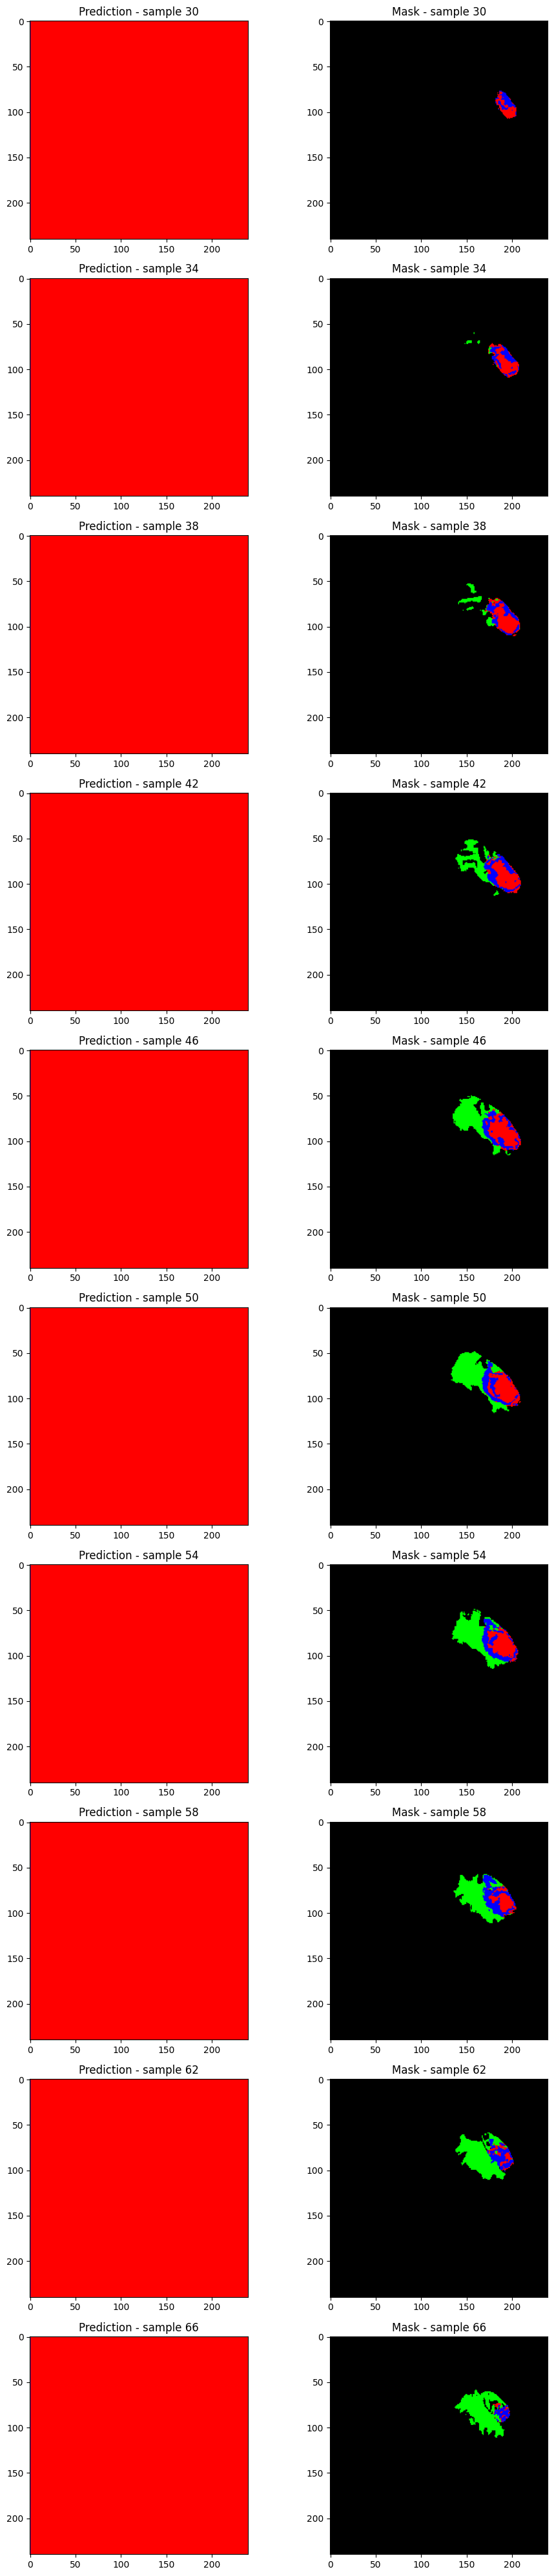

In [76]:
fold1_val = folds[0][1]
inputs = fold1_val[:]
ds = BRATSDataset(inputs, base_path=Path("../.."))

model = UNet(3)
model.load_state_dict(torch.load("../../models/UNET_20EPOCHS_0.005LR_BS64_FOLD2_final.pkl", weights_only=True))
model.eval()

sample_indices = [2, 7, 15, 23, 31, 42, 50, 61, 74, 88]
sample_indices = list(range(30, 70, 4))

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(10, 4 * len(sample_indices)))

for row, sample_index in enumerate(sample_indices):
    data = ds[sample_index]
    im = torch.from_numpy(data["image"]).unsqueeze(0)
    mask = np.moveaxis(data["mask"], 0, -1)
    with torch.no_grad():
        output = model(im)

    rgb = output[0].softmax(dim=0).permute(1, 2, 0).cpu().numpy()

    axes[row, 0].imshow(rgb[:, :, :])
    axes[row, 0].set_title(f"Prediction - sample {sample_index}")

    axes[row, 1].imshow(mask)
    axes[row, 1].set_title(f"Mask - sample {sample_index}")

plt.tight_layout()